# Fine Tuning with NASNetMobile

# Imports






In [ ]:
# !pip uninstall tf-keras
# !pip install tensorflow==2.16.1

In [2]:
!pip uninstall tf-keras
!pip install keras-tuner
!pip install tensorflow==2.16.1
!pip install ml_dtypes==0.5

Found existing installation: tf_keras 2.20.0
Uninstalling tf_keras-2.20.0:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/tf_keras-2.20.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/tf_keras/*
Proceed (Y/n)? y
  Successfully uninstalled tf_keras-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, which is not installed.
tensorflow 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.16.1 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.16.1 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
import keras
import tensorflow as tf
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

Keras Current Version: 3.13.2 Tensorflow Current Version: 2.16.1


In [2]:
import os, random, datetime
from glob import glob

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.optimizers import SGD
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.applications.nasnet import NASNetMobile, preprocess_input as preprocess_input_nasnet



# Functions

In [3]:
def get_image_paths(root_dir, num_images=None):
    all_images = []
    for extension in ['*.jpg', '*.jpeg', '*.png']:
        all_images.extend(glob(os.path.join(root_dir, '**', extension), recursive=True))
    if num_images is None:
        return all_images
    else:
        return random.sample(all_images, min(num_images, len(all_images)))


def print_predicted_classes(predicted_classes):
    for full_path, (label, probability) in predicted_classes.items():
        filename = os.path.basename(full_path)
        print(f"{filename}: {label} ({probability:.2f}%)")

def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()


# Data Preparation & Augmentation

# Task 1: Garbage Classification veri setini okuyunuz ve tüm resimlerin dizin bilgisini tutunuz.

# Task 1 Solution

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dir_path = '/content/drive/MyDrive/Colab Notebooks/CNN/datasets_and_files/Garbage classification'

In [6]:
img_list = get_image_paths(dir_path)

len(img_list)

2527

# Task 2: Data Augmentation teknikleri uygulayınız.

# Task 2 Solution

In [7]:
train = ImageDataGenerator(horizontal_flip=True,
                         vertical_flip=True,
                         validation_split=0.1,
                         rescale=1./255,
                         shear_range = 0.1,
                         zoom_range = 0.2,
                         width_shift_range = 0.2,
                         height_shift_range = 0.2,)


val = ImageDataGenerator(rescale=1/255,
                        validation_split=0.1)

In [8]:
train_generator=train.flow_from_directory(dir_path,
                                          target_size=(224, 224),
                                          batch_size=32,
                                          class_mode='categorical',
                                          subset='training')

validation_generator=val.flow_from_directory(dir_path,
                                        target_size=(224, 224),
                                        batch_size=251,
                                        class_mode='categorical',
                                        subset='validation')


Found 2276 images belonging to 6 classes.
Found 251 images belonging to 6 classes.


# Model

# Task 3: NASNetMobile backbone'unu uygun şekilde getiriniz.

# Task 3 Solution

In [9]:
from keras.applications.nasnet import NASNetMobile

In [10]:
NASNetMobile_backbone = NASNetMobile(include_top=False,
                                     weights='imagenet',
                                     input_shape=(224, 224, 3))

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
NASNetMobile_backbone.summary()


Model: "nasnet_mobile"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn1            │ (None, 111, 111,  │        128 │ stem_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 111, 111,  │          0 │ stem_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduction_conv_1_s… │ (None, 111, 111,  │        352 │ activation_188[0… │
│ (Conv2D)            │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduction_bn_1_ste… │ (None, 111, 111,  │         44 │ reduction_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 111, 111,  │          0 │ reduction_bn_1_s… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 111, 111,  │          0 │ stem_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_p… │ (None, 115, 115,  │          0 │ activation_189[0… │
│ (ZeroPadding2D)     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_p… │ (None, 117, 117,  │          0 │ activation_191[0… │
│ (ZeroPadding2D)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_r… │ (None, 56, 56,    │        396 │ separable_conv_1… │
│ (SeparableConv2D)   │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_r… │ (None, 56, 56,    │      1,920 │ separable_conv_1… │
│ (SeparableConv2D)   │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_b… │ (None, 56, 56,    │         44 │ separable_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_b… │ (None, 56, 56,    │         44 │ separable_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 56, 56,    │          0 │ separable_conv_1… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 56, 56,    │          0 │ separable_conv_1… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_2_r… │ (None, 56, 56,    │        396 │ activation_190[0

 Total params: 4,269,716 (16.29 MB)

 Trainable params: 4,232,978 (16.15 MB)

 Non-trainable params: 36,738 (143.51 KB)

In [ ]:
print(f"Total number of layers in NASNetMobile: {len(NASNetMobile_backbone.layers)}")

Total number of layers in NASNetMobile: 769


# Task 4: Modelin tüm katmanlarını dondurup sondan istediğiniz sayıda katmanı açık bırakınız.

# Task 4 Solution

In [ ]:
block_names = []


for layer in NASNetMobile_backbone.layers:
    if 'concat' in layer.name:
        block_names.append(layer.name)

print(f"Number of logical 'blocks' (Cells) in NASNetMobile: {len(block_names)}\n")

for i, name in enumerate(block_names, 1):
    print(f"Blok {i}: {name}")

Number of logical 'blocks' (Cells) in NASNetMobile: 20

Blok 1: reduction_concat_stem_1
Blok 2: concatenate_4
Blok 3: reduction_concat_stem_2
Blok 4: concatenate_5
Blok 5: normal_concat_0
Blok 6: normal_concat_1
Blok 7: normal_concat_2
Blok 8: normal_concat_3
Blok 9: reduction_concat_reduce_4
Blok 10: concatenate_6
Blok 11: normal_concat_5
Blok 12: normal_concat_6
Blok 13: normal_concat_7
Blok 14: normal_concat_8
Blok 15: reduction_concat_reduce_8
Blok 16: concatenate_7
Blok 17: normal_concat_9
Blok 18: normal_concat_10
Blok 19: normal_concat_11
Blok 20: normal_concat_12


In [11]:
NASNetMobile_backbone.trainable = False



In [12]:
start_unfreezing_layer_name = 'reduction_concat_reduce_4'

set_trainable = False

In [13]:
for layer in NASNetMobile_backbone.layers:
    if layer.name == start_unfreezing_layer_name:
        set_trainable = True

    if set_trainable:
        layer.trainable = True

print(f"'{start_unfreezing_layer_name}' katmanından sonrakiler eğitime açıldı.")

'reduction_concat_reduce_4' katmanından sonrakiler eğitime açıldı.


# Training

# Task 5: Modelin en üst katmanlarına gerekli katmanları ekleyiniz ve modelin input output ayarlamasını yapınız.

# Task 5 Solution

In [ ]:
x = NASNetMobile_backbone.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=NASNetMobile_backbone.input, outputs=predictions)

In [15]:
x = NASNetMobile_backbone.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)



# Task 6: Modeli compile ediniz.

- metric olarak sadece accuracy değerini kullanmanız yeterli.
- optimizer seçimine dikkat ediniz.


# Task 6 Solution

In [ ]:
fine_tuning_model = Model(inputs=NASNetMobile_backbone.input, outputs=x)

In [16]:
metrics = ["accuracy"]

In [ ]:
from tensorflow.keras.optimizers import SGD

In [17]:
optimizer=SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)

In [18]:
fine_tuning_model = Model(inputs=NASNetMobile_backbone.input, outputs=predictions)

fine_tuning_model.compile(optimizer=optimizer,
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

fine_tuning_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn1            │ (None, 111, 111,  │        128 │ stem_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ stem_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduction_conv_1_s… │ (None, 111, 111,  │        352 │ activation[0][0]  │
│ (Conv2D)            │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduction_bn_1_ste… │ (None, 111, 111,  │         44 │ reduction_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 111, 111,  │          0 │ reduction_bn_1_s… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 111, 111,  │          0 │ stem_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_p… │ (None, 115, 115,  │          0 │ activation_1[0][… │
│ (ZeroPadding2D)     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_p… │ (None, 117, 117,  │          0 │ activation_3[0][… │
│ (ZeroPadding2D)     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_r… │ (None, 56, 56,    │        396 │ separable_conv_1… │
│ (SeparableConv2D)   │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_r… │ (None, 56, 56,    │      1,920 │ separable_conv_1… │
│ (SeparableConv2D)   │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_b… │ (None, 56, 56,    │         44 │ separable_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_1_b… │ (None, 56, 56,    │         44 │ separable_conv_1… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ separable_conv_1… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 56, 56,    │          0 │ separable_conv_1… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv_2_r… │ (None, 56, 56,    │        396 │ activation_2[0][

 Total params: 4,541,850 (17.33 MB)

 Trainable params: 4,151,526 (15.84 MB)

 Non-trainable params: 390,324 (1.49 MB)

# Task 7: Callback'leri tanımlayınız.

# Task 7 Solution

In [19]:
fine_tuning_model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=metrics)

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=10,
                               restore_best_weights=True,
                               verbose=1)


model_checkpoint = ModelCheckpoint('NASNetMobile_finetuned.keras',
                                   monitor='val_loss',
                                   save_best_only=True,
                                   save_weights_only=False,
                                   verbose=1)

# Task 8: Modeli eğitiniz. Timer atmayı unutmayınız.



# Task 8 Solution

In [21]:
start_time = datetime.datetime.now()

fine_tuning_model_history = fine_tuning_model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    callbacks=[early_stopping, model_checkpoint]
)

end_time = datetime.datetime.now()

total_duration = end_time - start_time
print("Training Time:", total_duration)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1718 - loss: 1.9697
Epoch 1: val_loss improved from None to 1.64104, saving model to NASNetMobile_finetuned.keras

Epoch 1: finished saving model to NASNetMobile_finetuned.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 605s 8s/step - accuracy: 0.1911 - loss: 1.9242 - val_accuracy: 0.2869 - val_loss: 1.6410
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2551 - loss: 1.7585
Epoch 2: val_loss improved from 1.64104 to 1.49756, saving model to NASNetMobile_finetuned.keras

Epoch 2: finished saving model to NASNetMobile_finetuned.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.2851 - loss: 1.7066 - val_accuracy: 0.4064 - val_loss: 1.4976
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3497 - loss: 1.6185
Epoch 3: val_loss improved from 1.49756 to 1.38162, saving model to NASNetMobile_finetuned.keras

Epoch 3: finished saving model to NASNetMobile_finetuned.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/ste

# Task 9: Model sonuçlarını değerlendiriniz.

# Task 9: Solution

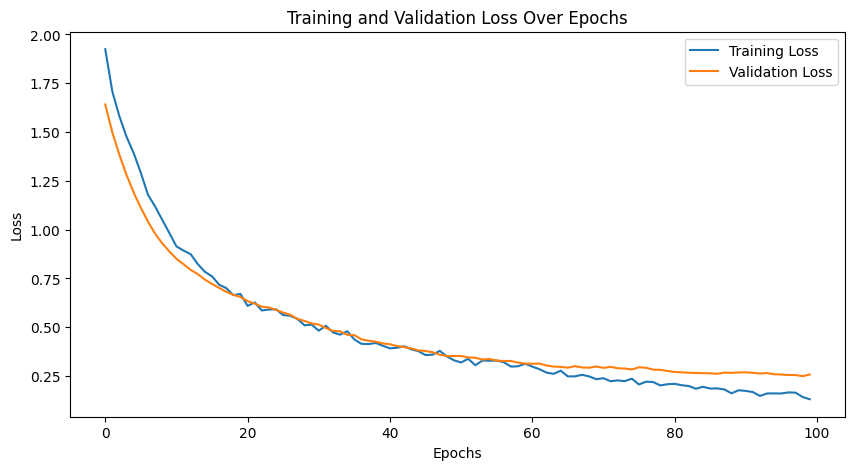

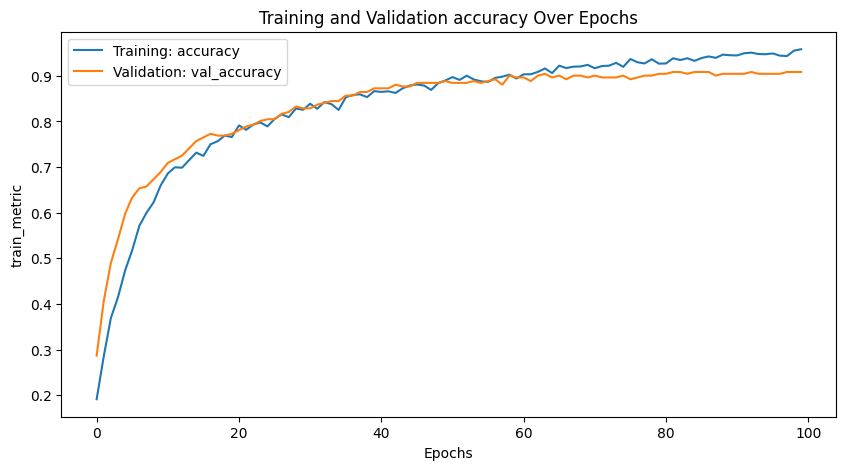

In [23]:
plot_training_history(fine_tuning_model_history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy')

In [25]:
val_loss, val_accuracy = fine_tuning_model.evaluate(validation_generator, verbose=0)
print(f"Loss: {val_loss}")
print(f"Accuracy: {val_accuracy}")

Loss: 0.24974213540554047
Accuracy: 0.9083665609359741


# Prediction

# Task 10: Model ile tahminlerde bulununuz.

- Dizinden 10 tane görsel seçiniz.

- Çalışma ortamınıza kaydettiğiniz modeli yükleyiniz.

- preprocess, predict ve visuallise_preds fonksiyonlarını yazarak bu 10 resim için tahminlerde bulununuz.

# Task 10: Solution

In [26]:
waste_labels = {0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}

In [28]:
dir_path = '/content/drive/MyDrive/Colab Notebooks/CNN/datasets_and_files/Garbage classification'

In [29]:
img_list = get_image_paths(dir_path, 10)

In [30]:
garbage_full_tuned_model = load_model('NASNetMobile_finetuned.keras')

In [32]:
def preprocess_NASNetMobile(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input_nasnet(img_array)
    return img_array

def predict_NASNetMobile(model, img_array, class_labels):
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_labels[predicted_class_idx]
    probability = np.max(predictions[0])
    return predicted_class, probability

def visualise_preds_NASNetMobile(model, image_paths, class_labels, visualize=False):
      results = {}
      for img_path in image_paths:
        img_array = preprocess_NASNetMobile(img_path)
        label, probability = predict_NASNetMobile(model, img_array, class_labels)
        results[img_path] = (label, probability)
        if visualize:
            plt.figure(figsize=(5, 5))
            plt.imshow(image.load_img(img_path))
            plt.title(f"Predicted: {label} ({probability:.2f}%)")
            plt

      return results

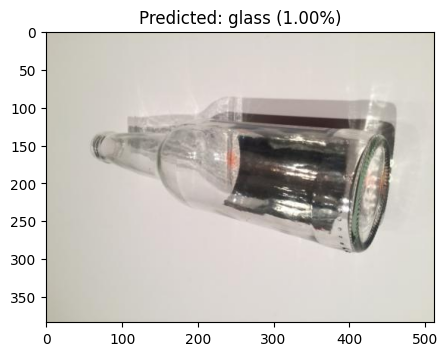

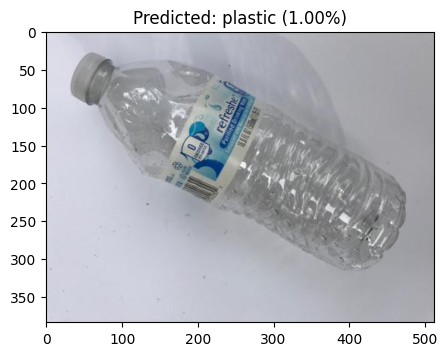

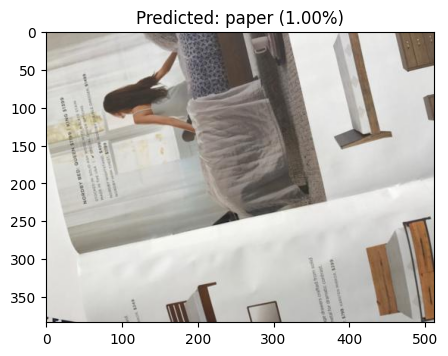

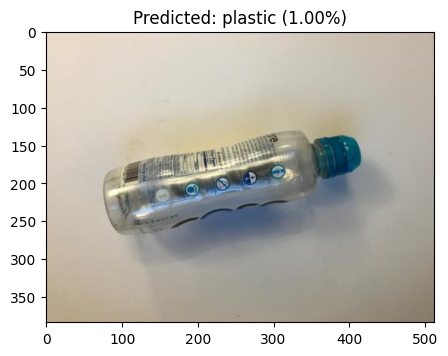

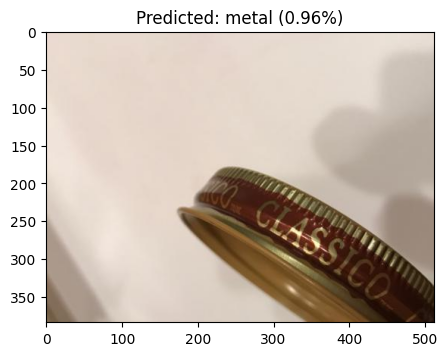

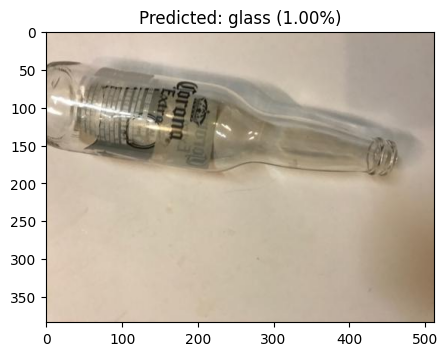

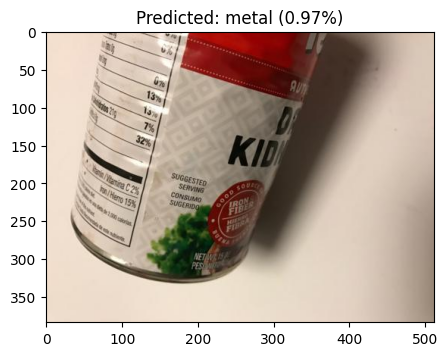

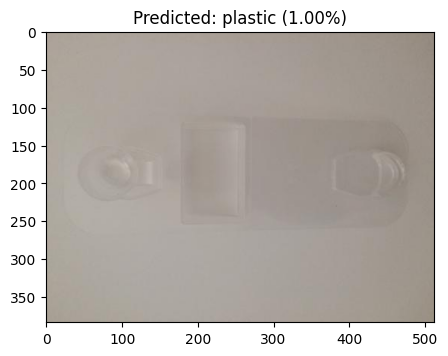

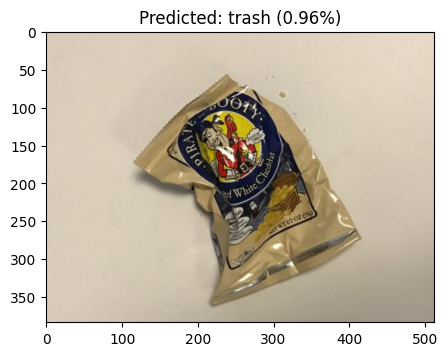

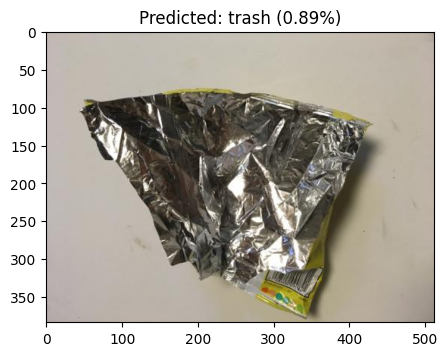

In [33]:
predicted_classes = visualise_preds_NASNetMobile(garbage_full_tuned_model, img_list, waste_labels, visualize=True)

In [34]:
print_predicted_classes(predicted_classes)

glass248.jpg: glass (1.00%)
plastic224.jpg: plastic (1.00%)
paper455.jpg: paper (1.00%)
plastic359.jpg: plastic (1.00%)
metal256.jpg: metal (0.96%)
glass104.jpg: glass (1.00%)
metal97.jpg: metal (0.97%)
plastic2.jpg: plastic (1.00%)
trash28.jpg: trash (0.96%)
trash112.jpg: trash (0.89%)


In [35]:
img_list2 = get_image_paths(dir_path, 50)

In [38]:
predicted_classes2 = visualise_preds_NASNetMobile(garbage_full_tuned_model, img_list2, waste_labels, False)

In [39]:
print_predicted_classes(predicted_classes2)

metal105.jpg: metal (0.91%)
plastic230.jpg: plastic (1.00%)
paper122.jpg: paper (0.48%)
cardboard162.jpg: cardboard (0.80%)
glass222.jpg: glass (0.58%)
glass227.jpg: glass (1.00%)
cardboard57.jpg: cardboard (1.00%)
glass82.jpg: glass (1.00%)
plastic97.jpg: plastic (0.97%)
cardboard147.jpg: cardboard (1.00%)
paper313.jpg: paper (1.00%)
metal135.jpg: metal (1.00%)
cardboard319.jpg: cardboard (1.00%)
paper429.jpg: paper (1.00%)
plastic178.jpg: plastic (1.00%)
glass415.jpg: glass (0.99%)
paper415.jpg: paper (0.95%)
plastic183.jpg: plastic (0.99%)
paper293.jpg: paper (1.00%)
metal266.jpg: metal (0.97%)
plastic102.jpg: plastic (1.00%)
plastic429.jpg: plastic (1.00%)
paper330.jpg: paper (1.00%)
glass14.jpg: glass (0.99%)
paper244.jpg: paper (1.00%)
cardboard44.jpg: cardboard (1.00%)
paper100.jpg: paper (0.99%)
metal98.jpg: metal (0.98%)
paper21.jpg: paper (0.99%)
cardboard166.jpg: cardboard (0.61%)
cardboard376.jpg: cardboard (1.00%)
plastic291.jpg: plastic (1.00%)
metal11.jpg: metal (0.97%)
